#Environment Setup & Data Loading


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image, ImageOps
from google.colab import files
import io

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
torch.cuda.is_available()

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Go into your Google Drive
%cd /content/drive/MyDrive/

# Move into that specific folder
%cd Colab_Projects/BHDD_Model

!git clone https://github.com/baseresearch/BHDD.git

/content/drive/MyDrive
/content/drive/MyDrive/Colab_Projects/BHDD_Model
fatal: destination path 'BHDD' already exists and is not an empty directory.


In [ ]:
import pickle

file_path = "/content/drive/MyDrive/Colab_Projects/BHDD_Model/BHDD/data.pkl"

with open(file_path, "rb") as file:
  data = pickle.load(file)

print(type(data))

<class 'dict'>


In [ ]:
print(data.keys())

dict_keys(['trainDataset', 'testDataset'])


#Data Exploration

In [ ]:
train_data = data['trainDataset']
test_data = data['testDataset']
print(type(train_data))
print(len(train_data))

<class 'list'>
60000


In [ ]:
first_item = train_data[0]
print("Type:" , type(first_item))

if type(first_item) in [tuple, list]:
  print("Length:" ,len(first_item))
elif type(first_item) == dict:
  print("Keys:" , first_item.keys())

Type: <class 'dict'>
Keys: dict_keys(['image', 'label'])


In [ ]:
image_data = first_item['image']
label_data = first_item['label']

print("Image type:", type(image_data))
print("Lable type:", type(label_data))
print("Label value:", label_data)

if hasattr(image_data, 'shape'):
  print("Image shape:", image_data.shape)
elif hasattr(image_data, 'size'):
  print("Image size:", image_data.size)

Image type: <class 'numpy.ndarray'>
Lable type: <class 'numpy.uint8'>
Label value: 8
Image shape: (28, 28)


#Data Pipeline & Augmentation

In [ ]:
class BurmeseDigitDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        current_item = self.data[idx]
        image_data = current_item['image']
        label_data = current_item['label']

        #convert the raw numpy array into a PIL Image
        pil_image = Image.fromarray(image_data)

        #apply the mutations
        if self.transform:
            image_tensor = self.transform(pil_image)
        else:
            image_tensor = transforms.ToTensor()(pil_image)

        #convert label
        label_tensor = torch.tensor(label_data).long()

        return image_tensor, label_tensor

In [ ]:
train_transform_pipeline = transforms.Compose([
    transforms.RandomRotation(degrees=15),

    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.7, 1.1)),

    #convert to the [1, 28, 28] float tensor
    transforms.ToTensor()
])

augmented_train_dataset = BurmeseDigitDataset(train_data, transform=train_transform_pipeline)
train_loader = DataLoader(augmented_train_dataset, batch_size=32, shuffle=True)

test_dataset = BurmeseDigitDataset(test_data, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Augmented Data Pipeline")

Augmented Data Pipeline


In [ ]:
train_dataset = BurmeseDigitDataset(train_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 1, 28, 28])
Labels shape: torch.Size([32])


#Neural Network Architecture

In [ ]:
class BurmeseDigitCNN(nn.Module):
    def __init__(self):
        super(BurmeseDigitCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(in_features=16 * 14 * 14, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)

        return x

In [ ]:
class BurmeseDigitCNN_V2(nn.Module):
    def __init__(self):
        super(BurmeseDigitCNN_V2, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(in_features=32 * 7 * 7, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        # pass 1
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2) # image 14 x 14

        # pass 2
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2) # image 7 x 7

        # classifier
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x


model = BurmeseDigitCNN_V2()
print("CNNV2 Installed")

CNNV2 Installed


In [ ]:
dummy_images = torch.randn(32, 1, 28, 28)

model = BurmeseDigitCNN_V2()

predictions = model(dummy_images)

print("Model Output Shape:", predictions.shape)

Model Output Shape: torch.Size([32, 10])


#Training & Evaluation

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

print("V2 Training Loop on Augmented Data")

for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:

        predictions = model(images)
        loss = criterion(predictions, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Average Loss: {avg_loss:.4f}")

print("V2 Training Complete!")

V2 Training Loop on Augmented Data
Epoch 1/20 | Average Loss: 0.1060
Epoch 2/20 | Average Loss: 0.0210
Epoch 3/20 | Average Loss: 0.0136
Epoch 4/20 | Average Loss: 0.0089
Epoch 5/20 | Average Loss: 0.0068
Epoch 6/20 | Average Loss: 0.0050
Epoch 7/20 | Average Loss: 0.0047
Epoch 8/20 | Average Loss: 0.0028
Epoch 9/20 | Average Loss: 0.0035
Epoch 10/20 | Average Loss: 0.0027
Epoch 11/20 | Average Loss: 0.0019
Epoch 12/20 | Average Loss: 0.0028
Epoch 13/20 | Average Loss: 0.0019
Epoch 14/20 | Average Loss: 0.0010
Epoch 15/20 | Average Loss: 0.0014
Epoch 16/20 | Average Loss: 0.0015
Epoch 17/20 | Average Loss: 0.0014
Epoch 18/20 | Average Loss: 0.0019
Epoch 19/20 | Average Loss: 0.0010
Epoch 20/20 | Average Loss: 0.0010
V2 Training Complete!


In [ ]:
test_data = data['testDataset']
test_dataset = BurmeseDigitDataset(test_data)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

correct_guesses = 0
total_images = 0

with torch.no_grad():
    for images, labels in test_loader:

        predictions = model(images)

        _, predicted_classes = torch.max(predictions, dim=1)

        total_images += labels.size(0)
        correct_guesses += (predicted_classes == labels).sum().item()

accuracy = 100 * (correct_guesses / total_images)
print(f"Final Model Accuracy on Unseen Data: {accuracy:.2f}%")

Final Model Accuracy on Unseen Data: 99.69%


#Real-World Inference

👇 Upload your thin, custom handwriting images:


Saving 9.jpg to 9 (6).jpg
Saving 7.jpg to 7 (6).jpg
Saving 6.jpg to 6 (6).jpg
Saving 5.jpg to 5 (5).jpg
Saving 4.jpg to 4 (6).jpg
Saving 3.jpg to 3 (6).jpg
Saving 2.jpg to 2 (6).jpg
Saving 1.jpg to 1 (6).jpg


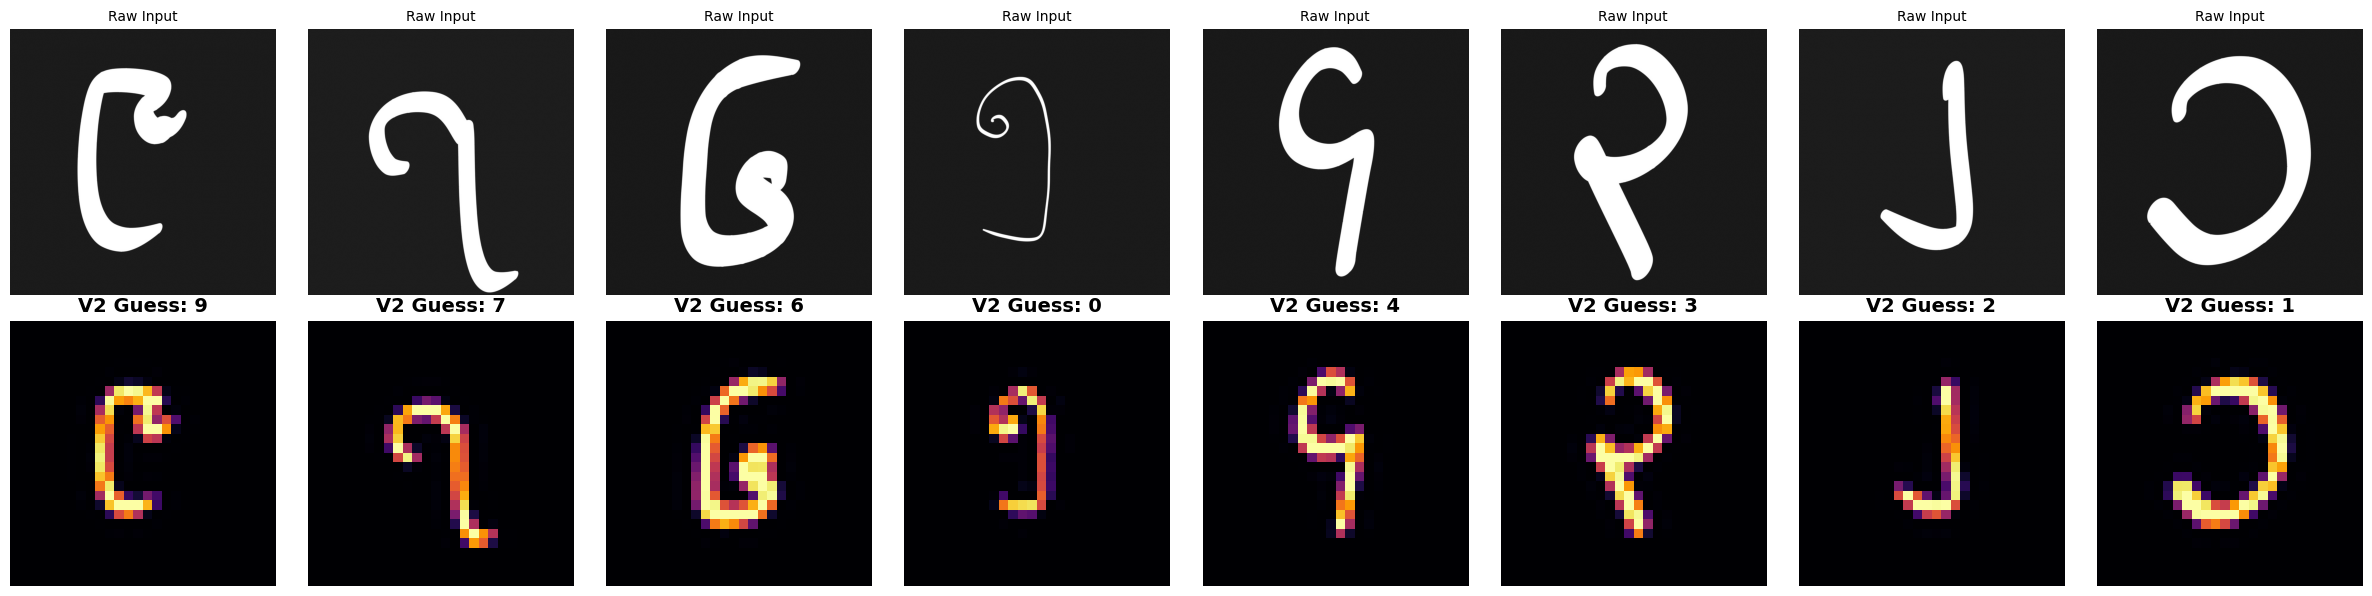

In [ ]:
def fit_and_pad(img, target_size=28, digit_size=20):

    img = img.point(lambda p: 255 if p > 128 else 0)

    img.thumbnail((digit_size, digit_size), Image.Resampling.LANCZOS)
    new_img = Image.new("L", (target_size, target_size), color=0)
    paste_x = (target_size - img.width) // 2
    paste_y = (target_size - img.height) // 2
    new_img.paste(img, (paste_x, paste_y))
    return new_img

print("Upload custom handwriting images:")
uploaded = files.upload()

num_images = len(uploaded)
if num_images > 0:
    model.eval()

    fig, axes = plt.subplots(2, num_images, figsize=(3 * num_images, 6))
    if num_images == 1:
        axes = [[axes[0]], [axes[1]]]

    for i, (filename, file_data) in enumerate(uploaded.items()):
        raw_image = Image.open(io.BytesIO(file_data)).convert('L')

        processed_pil_image = fit_and_pad(raw_image)

        image_tensor = transforms.ToTensor()(processed_pil_image).unsqueeze(0)

        with torch.no_grad():
            output = model(image_tensor)
            _, predicted_index = torch.max(output, 1)
            prediction = predicted_index.item()

        axes[0][i].imshow(raw_image, cmap='gray')
        axes[0][i].set_title("Raw Input", fontsize=10)
        axes[0][i].axis('off')

        tensor_to_show = image_tensor.squeeze().numpy()
        axes[1][i].imshow(tensor_to_show, cmap='inferno')
        axes[1][i].set_title(f"V2 Guess: {prediction}", fontsize=14, fontweight='bold')
        axes[1][i].axis('off')

    plt.tight_layout()
    plt.show()